# 28 — Corpus-group right dictionary (Archaic + Classical Greek)

Builds a 9-resource integer dictionary per observed corpus criterion-cell (with `*` for unspecified axes), applies five asymmetric markedness rules with a "can't be saved" guard, thresholds to a binary right vector, then imputes the unobserved combinations.

In [1]:
from pathlib import Path
from itertools import product

import pandas as pd
import numpy as np

pd.set_option('display.max_colwidth', 240)
pd.set_option('display.max_rows', 200)

ROOT = Path('..').resolve()
RULES_PATH = ROOT / 'data/clean/final/rules_with_criteria.tsv'

In [2]:
AXES = [
    'c_sex',
    'c_age',
    'c_ownership_status',
    'c_ancestry',
    'c_residence',
    'c_wealth',
]

AXIS_BINARY_PAIR = {
    'c_sex':              ('Male',     'Female'),
    'c_age':              ('Adult',    'Minor'),
    'c_ownership_status': ('Free',     'Enslaved'),
    'c_ancestry':         ('Native',   'Foreign'),
    'c_residence':        ('Resident', 'Non resident'),
}

In [3]:
ORTHOGONAL_RESOURCES = [
    'Eligibility for public office',
    'Right to a legal trial',
    'Right to vote / public speech',
    'Right to property (retain / dispose / inherit)',
    'Right to marriage / dowry',
    'Protection from capital / corporal punishment',
]

RESOURCE_TO_BUCKET = {
    'Eligibility for public office':                  'Eligibility for public office',
    'Right to remuneration for office':               'Eligibility for public office',
    'Right to a legal trial':                         'Right to a legal trial',
    'Right to professional judgement':                'Right to a legal trial',
    'Right to valid professional opinion':            'Right to a legal trial',
    'Right to vote in the Ekklesia':                  'Right to vote / public speech',
    'Right to address the assembly':                  'Right to vote / public speech',
    'Right to speak first in assembly':               'Right to vote / public speech',
    'Right to free speech':                           'Right to vote / public speech',
    'Right to public speech':                         'Right to vote / public speech',
    'Right to retain property':                       'Right to property (retain / dispose / inherit)',
    'Right to retain own earnings':                   'Right to property (retain / dispose / inherit)',
    'Right to own land':                              'Right to property (retain / dispose / inherit)',
    'Right to own property':                          'Right to property (retain / dispose / inherit)',
    'Right to dispose of property':                   'Right to property (retain / dispose / inherit)',
    'Right to inherit property':                      'Right to property (retain / dispose / inherit)',
    'Right to dispose / inherit property':            'Right to property (retain / dispose / inherit)',
    'Right to a dowry':                               'Right to marriage / dowry',
    'Right to marry':                                 'Right to marriage / dowry',
    'Right to marriage / dowry':                      'Right to marriage / dowry',
    'Protection from capital punishment':             'Protection from capital / corporal punishment',
    'Protection from corporal punishment':            'Protection from capital / corporal punishment',
    'Protection from capital / corporal punishment':  'Protection from capital / corporal punishment',
}

In [4]:
def normalize_axis_token(value):
    if pd.isna(value): return '*'
    text = str(value)
    if text in ('any', 'unspecified'): return '*'
    return text.replace('_', ' ').capitalize()

rules_raw = pd.read_csv(RULES_PATH, sep='\t')
rules_raw['rule_criterion_signature'] = rules_raw.apply(
    lambda row: '/'.join(normalize_axis_token(row[axis]) for axis in AXES), axis=1,
)
rules_raw['resource_bucket'] = rules_raw['resource_meta'].map(RESOURCE_TO_BUCKET)

print('rules_raw.shape =', rules_raw.shape)
rules_raw[['rule_id','group','directionality','resource_meta','resource_bucket','rule_polity','rule_criterion_signature']].head()

rules_raw.shape = (1011, 49)


,rule_id,group,directionality,resource_meta,resource_bucket,rule_polity,rule_criterion_signature
0,tlg0007.tlg118.perseus-eng3::0,Greeks,LESS,Political power,NaN,Roman Empire,*/*/*/Foreign/*/*
1,tlg0007.tlg118.perseus-eng3::1,Citizens of Greek city-states,MORE,Political power,NaN,Roman Empire,Male/Adult/Free/Native/Resident/*
2,tlg0007.tlg118.perseus-eng3::2,Nobles,MORE,Eligibility for public office,Eligibility for public office,Roman Empire,*/Adult/Free/Native/*/High
3,tlg0007.tlg118.perseus-eng3::3,Citizens,MORE,Right to vote in the Ekklesia,Right to vote / public speech,Roman Empire,Male/Adult/Free/Mixed/*/*
4,tlg0007.tlg118.perseus-eng3::5,Citizens,LESS,Political power,NaN,Roman Empire,Male/Adult/Free/Mixed/*/*


In [5]:
archaic_classical_polities = sorted({
    polity for polity in rules_raw['rule_polity'].dropna().unique()
    if 'Archaic' in polity or 'Classical' in polity
})

rules_in_scope = rules_raw[
    rules_raw['rule_polity'].isin(archaic_classical_polities)
    & (rules_raw['requires_rights_definition'] != True)
    & (rules_raw['tautology'] != 1)
    & rules_raw['resource_bucket'].isin(ORTHOGONAL_RESOURCES)
    & rules_raw['directionality'].isin(['MORE','LESS'])
].copy()

print('rules_in_scope.shape =', rules_in_scope.shape)
print('  MORE =', (rules_in_scope['directionality']=='MORE').sum())
print('  LESS =', (rules_in_scope['directionality']=='LESS').sum())
print('  distinct criterion-cells =', rules_in_scope['rule_criterion_signature'].nunique())
rules_in_scope[['rule_id','group','directionality','resource_bucket','rule_polity','rule_criterion_signature']].head()

rules_in_scope.shape = (389, 49)
  MORE = 244
  LESS = 145
  distinct criterion-cells = 56


,rule_id,group,directionality,resource_bucket,rule_polity,rule_criterion_signature
10,tlg0014.tlg059.perseus-eng2::3,Aliens,LESS,Right to marriage / dowry,Classical Athens,*/*/Free/Foreign/Resident/*
13,tlg0014.tlg059.perseus-eng2::7,Wives,MORE,Right to marriage / dowry,Classical Athens,Female/Adult/Free/*/Resident/*
16,tlg0014.tlg059.perseus-eng2::12,Slaves,LESS,Protection from capital / corporal punishment,Classical Athens,*/*/Enslaved/*/Resident/Low
17,tlg0032.tlg015.perseus-eng1::0,The poor,MORE,Eligibility for public office,Classical Athens,*/*/Free/*/Resident/Low
18,tlg0032.tlg015.perseus-eng1::1,The poor,MORE,Right to vote / public speech,Classical Athens,*/*/Free/*/Resident/Low


## Distribution of rules — per resource and per group

In [6]:
import matplotlib.pyplot as plt

resource_counts = (rules_in_scope.groupby(['resource_bucket', 'directionality']).size()
                   .unstack('directionality', fill_value=0)
                   .reindex(ORTHOGONAL_RESOURCES))
resource_counts['total'] = resource_counts.sum(axis=1)
resource_counts = resource_counts.sort_values('total', ascending=True)
print('resource_counts.shape =', resource_counts.shape)
resource_counts

resource_counts.shape = (6, 3)


directionality,LESS,MORE,total
resource_bucket,,,
Right to marriage / dowry,1,12,13
Right to vote / public speech,21,32,53
Protection from capital / corporal punishment,33,22,55
Right to a legal trial,11,48,59
Right to property (retain / dispose / inherit),49,43,92
Eligibility for public office,30,87,117


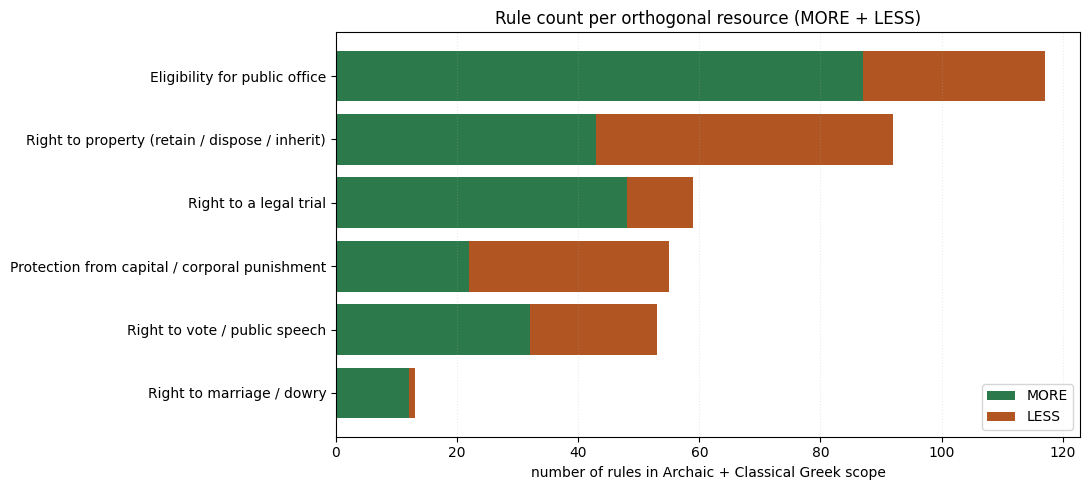

In [7]:
fig, ax = plt.subplots(figsize=(11, 5))
y_positions = np.arange(len(resource_counts))
ax.barh(y_positions, resource_counts['MORE'], color='#2c7a4b', label='MORE')
ax.barh(y_positions, resource_counts['LESS'], left=resource_counts['MORE'],
        color='#b15623', label='LESS')
ax.set_yticks(y_positions)
ax.set_yticklabels(resource_counts.index, fontsize=10)
ax.set_xlabel('number of rules in Archaic + Classical Greek scope')
ax.set_title('Rule count per orthogonal resource (MORE + LESS)')
ax.legend(loc='lower right')
ax.grid(axis='x', alpha=0.25, linestyle=':')
plt.tight_layout()
plt.show()

In [8]:
group_counts = (rules_in_scope.groupby('rule_criterion_signature').size()
                .rename('n_rules')
                .sort_values(ascending=False)
                .reset_index()
                .rename(columns={'rule_criterion_signature': 'criterion_cell'}))
print('group_counts.shape =', group_counts.shape)
group_counts.head(15)

group_counts.shape = (56, 2)


,criterion_cell,n_rules
0,Male/Adult/Free/Native/Resident/*,122
1,*/*/Enslaved/*/Resident/Low,36
2,*/Adult/Free/*/Resident/High,25
3,*/*/Free/*/Resident/Low,18
4,Female/*/*/*/Resident/*,18
5,Male/Adult/Free/Native/Resident/High,15
6,*/*/Free/Native/Resident/*,11
7,*/*/Free/Foreign/*/*,9
8,*/Minor/Free/Native/Resident/*,8
9,*/Adult/Free/Foreign/Resident/*,8


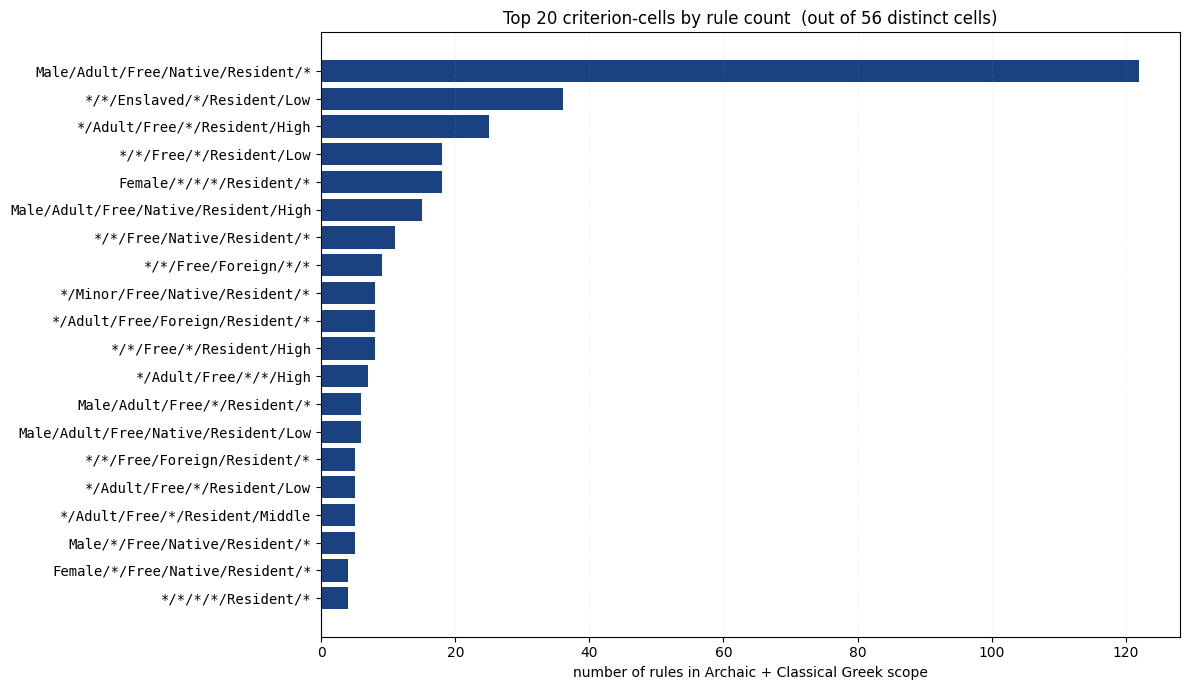

In [9]:
N_TOP_CELLS_TO_PLOT = 20

top_cell_counts = group_counts.head(N_TOP_CELLS_TO_PLOT).iloc[::-1]
fig, ax = plt.subplots(figsize=(12, 7))
ax.barh(np.arange(len(top_cell_counts)), top_cell_counts['n_rules'], color='#1a4280')
ax.set_yticks(np.arange(len(top_cell_counts)))
ax.set_yticklabels(top_cell_counts['criterion_cell'], fontsize=10, family='monospace')
ax.set_xlabel('number of rules in Archaic + Classical Greek scope')
ax.set_title(f'Top {N_TOP_CELLS_TO_PLOT} criterion-cells by rule count  (out of {len(group_counts)} distinct cells)')
ax.grid(axis='x', alpha=0.25, linestyle=':')
plt.tight_layout()
plt.show()

In [10]:
def top_n_corpus_groups_at_cell(group_series, top_n=5):
    counts = group_series.value_counts()
    return '; '.join(counts.head(top_n).index.tolist())

corpus_cells = (
    rules_in_scope.groupby('rule_criterion_signature')
        .agg(
            n_rules=('rule_id', 'size'),
            n_more=('directionality', lambda x: (x == 'MORE').sum()),
            n_less=('directionality', lambda x: (x == 'LESS').sum()),
            top_5_groups=('group', lambda x: top_n_corpus_groups_at_cell(x, top_n=5)),
        )
        .reset_index()
        .sort_values('n_rules', ascending=False)
        .reset_index(drop=True)
)
corpus_cells['gid'] = ['G' + str(i + 1) for i in range(len(corpus_cells))]
corpus_cells = corpus_cells[['gid', 'rule_criterion_signature', 'top_5_groups', 'n_rules', 'n_more', 'n_less']]
print('corpus_cells.shape =', corpus_cells.shape)
corpus_cells.head(15)

corpus_cells.shape = (56, 6)


,gid,rule_criterion_signature,top_5_groups,n_rules,n_more,n_less
0,G1,Male/Adult/Free/Native/Resident/*,Citizens; Men over thirty; Rural citizens; Men who have prostituted themselves; Athenian citizens,122,99,23
1,G2,*/*/Enslaved/*/Resident/Low,Slaves,36,10,26
2,G3,*/Adult/Free/*/Resident/High,The wealthy; The rich; Owners of estates; Property owners,25,11,14
3,G4,*/*/Free/*/Resident/Low,The poor,18,13,5
4,G5,Female/*/*/*/Resident/*,Women,18,13,5
5,G6,Male/Adult/Free/Native/Resident/High,Wealthy citizens; The wealthy and noble; Eupatridae; Wealthy property owners; Pentacosiomedimni,15,11,4
6,G7,*/*/Free/Native/Resident/*,Athenians; Ancient family members,11,7,4
7,G8,*/*/Free/Foreign/*/*,Foreigners,9,4,5
8,G9,*/Minor/Free/Native/Resident/*,Minors,8,3,5
9,G10,*/Adult/Free/Foreign/Resident/*,Metics,8,2,6


## Build the integer dictionary per (group, resource)

For each corpus cell `G` and each of the 6 resources `R`:

- `direct_more(G, R)` — MORE rules whose criterion signature is refined by `G`.
- `direct_less(G, R)` — LESS rules whose criterion signature is refined by `G`.

Integer count:

$$
\text{count}(G, R) \;=\; \text{direct\_more}(G, R) \;-\; \text{direct\_less}(G, R)
$$

In [11]:
def cell_refines_rule(cell_signature, rule_signature):
    for cell_value, rule_value in zip(cell_signature.split('/'), rule_signature.split('/')):
        if rule_value == '*':
            continue
        if rule_value == 'Middle':
            return False
        if cell_value == '*':
            return False
        if cell_value != rule_value:
            return False
    return True

cell_signatures   = corpus_cells['rule_criterion_signature'].tolist()
cell_to_index     = {sig: i for i, sig in enumerate(cell_signatures)}
resource_to_index = {res: i for i, res in enumerate(ORTHOGONAL_RESOURCES)}

n_cells     = len(cell_signatures)
n_resources = len(ORTHOGONAL_RESOURCES)

direct_more = np.zeros((n_cells, n_resources), dtype=int)
direct_less = np.zeros_like(direct_more)

for _, rule in rules_in_scope.iterrows():
    rule_signature = rule['rule_criterion_signature']
    resource_idx   = resource_to_index[rule['resource_bucket']]
    direction      = rule['directionality']
    for cell_sig in cell_signatures:
        if cell_refines_rule(cell_sig, rule_signature):
            if direction == 'MORE':
                direct_more[cell_to_index[cell_sig], resource_idx] += 1
            else:
                direct_less[cell_to_index[cell_sig], resource_idx] += 1

integer_count = direct_more - direct_less

print('direct_more.shape   =', direct_more.shape,   '  total =', int(direct_more.sum()))
print('direct_less.shape   =', direct_less.shape,   '  total =', int(direct_less.sum()))
print('integer_count.shape =', integer_count.shape)

integer_count_table = pd.DataFrame(integer_count, columns=ORTHOGONAL_RESOURCES)
integer_count_table.insert(0, 'gid',          corpus_cells['gid'].values)
integer_count_table.insert(1, 'cell',         corpus_cells['rule_criterion_signature'].values)
integer_count_table.insert(2, 'top_5_groups', corpus_cells['top_5_groups'].values)
integer_count_table.head(15)

direct_more.shape   = (56, 6)   total = 1415
direct_less.shape   = (56, 6)   total = 807
integer_count.shape = (56, 6)


,gid,cell,top_5_groups,Eligibility for public office,Right to a legal trial,Right to vote / public speech,Right to property (retain / dispose / inherit),Right to marriage / dowry,Protection from capital / corporal punishment
0,G1,Male/Adult/Free/Native/Resident/*,Citizens; Men over thirty; Rural citizens; Men who have prostituted themselves; Athenian citizens,35,34,11,9,0,1
1,G2,*/*/Enslaved/*/Resident/Low,Slaves,0,0,-1,1,0,-13
2,G3,*/Adult/Free/*/Resident/High,The wealthy; The rich; Owners of estates; Property owners,9,1,2,-10,0,2
3,G4,*/*/Free/*/Resident/Low,The poor,4,0,3,1,0,3
4,G5,Female/*/*/*/Resident/*,Women,-1,-2,3,2,7,2
5,G6,Male/Adult/Free/Native/Resident/High,Wealthy citizens; The wealthy and noble; Eupatridae; Wealthy property owners; Pentacosiomedimni,61,34,11,-4,0,1
6,G7,*/*/Free/Native/Resident/*,Athenians; Ancient family members,4,2,1,-2,0,0
7,G8,*/*/Free/Foreign/*/*,Foreigners,1,0,2,-4,0,1
8,G9,*/Minor/Free/Native/Resident/*,Minors,1,2,0,-2,0,0
9,G10,*/Adult/Free/Foreign/Resident/*,Metics,-1,1,2,-8,-1,4


### Integer dictionary — clean visual table

A PNG rendering of the top 15 corpus cells. Each resource cell shows `(+more, -less)` — the number of MORE rules followed by the number of LESS rules attributable to that group on that resource. Distasteful corpus group labels are filtered out before display.

In [12]:
N_TOP_CELLS_FOR_PNG = 15
HIDDEN_GROUP_LABELS = {
    'Men who have prostituted themselves',
}

def clean_top_groups(text):
    if not isinstance(text, str):
        return text
    kept = [part.strip() for part in text.split(';') if part.strip() not in HIDDEN_GROUP_LABELS]
    return '; '.join(kept)

def format_more_less(more_count, less_count):
    return f'(+{int(more_count)}, -{int(less_count)})'

top_cell_signatures = corpus_cells['rule_criterion_signature'].head(N_TOP_CELLS_FOR_PNG).tolist()

display_table = pd.DataFrame({
    'gid':          corpus_cells['gid'].head(N_TOP_CELLS_FOR_PNG).values,
    'cell':         top_cell_signatures,
    'top_5_groups': corpus_cells['top_5_groups'].head(N_TOP_CELLS_FOR_PNG).map(clean_top_groups).values,
})
for resource_idx, resource_name in enumerate(ORTHOGONAL_RESOURCES):
    display_table[resource_name] = [
        format_more_less(direct_more[cell_to_index[sig], resource_idx],
                         direct_less[cell_to_index[sig], resource_idx])
        for sig in top_cell_signatures
    ]
display_table

,gid,cell,top_5_groups,Eligibility for public office,Right to a legal trial,Right to vote / public speech,Right to property (retain / dispose / inherit),Right to marriage / dowry,Protection from capital / corporal punishment
0,G1,Male/Adult/Free/Native/Resident/*,Citizens; Men over thirty; Rural citizens; Athenian citizens,"(+42, -7)","(+37, -3)","(+23, -12)","(+19, -10)","(+0, -0)","(+9, -8)"
1,G2,*/*/Enslaved/*/Resident/Low,Slaves,"(+0, -0)","(+3, -3)","(+2, -3)","(+5, -4)","(+0, -0)","(+5, -18)"
2,G3,*/Adult/Free/*/Resident/High,The wealthy; The rich; Owners of estates; Property owners,"(+11, -2)","(+3, -2)","(+3, -1)","(+9, -19)","(+0, -0)","(+4, -2)"
3,G4,*/*/Free/*/Resident/Low,The poor,"(+7, -3)","(+1, -1)","(+6, -3)","(+3, -2)","(+0, -0)","(+3, -0)"
4,G5,Female/*/*/*/Resident/*,Women,"(+0, -1)","(+0, -2)","(+3, -0)","(+6, -4)","(+7, -0)","(+2, -0)"
5,G6,Male/Adult/Free/Native/Resident/High,Wealthy citizens; The wealthy and noble; Eupatridae; Wealthy property owners; Pentacosiomedimni,"(+69, -8)","(+38, -4)","(+23, -12)","(+26, -30)","(+0, -0)","(+11, -10)"
6,G7,*/*/Free/Native/Resident/*,Athenians; Ancient family members,"(+4, -0)","(+4, -2)","(+3, -2)","(+2, -4)","(+0, -0)","(+2, -2)"
7,G8,*/*/Free/Foreign/*/*,Foreigners,"(+1, -0)","(+2, -2)","(+2, -0)","(+2, -6)","(+0, -0)","(+1, -0)"
8,G9,*/Minor/Free/Native/Resident/*,Minors,"(+4, -3)","(+4, -2)","(+3, -3)","(+2, -4)","(+0, -0)","(+5, -5)"
9,G10,*/Adult/Free/Foreign/Resident/*,Metics,"(+2, -3)","(+5, -4)","(+4, -2)","(+4, -12)","(+0, -1)","(+5, -1)"


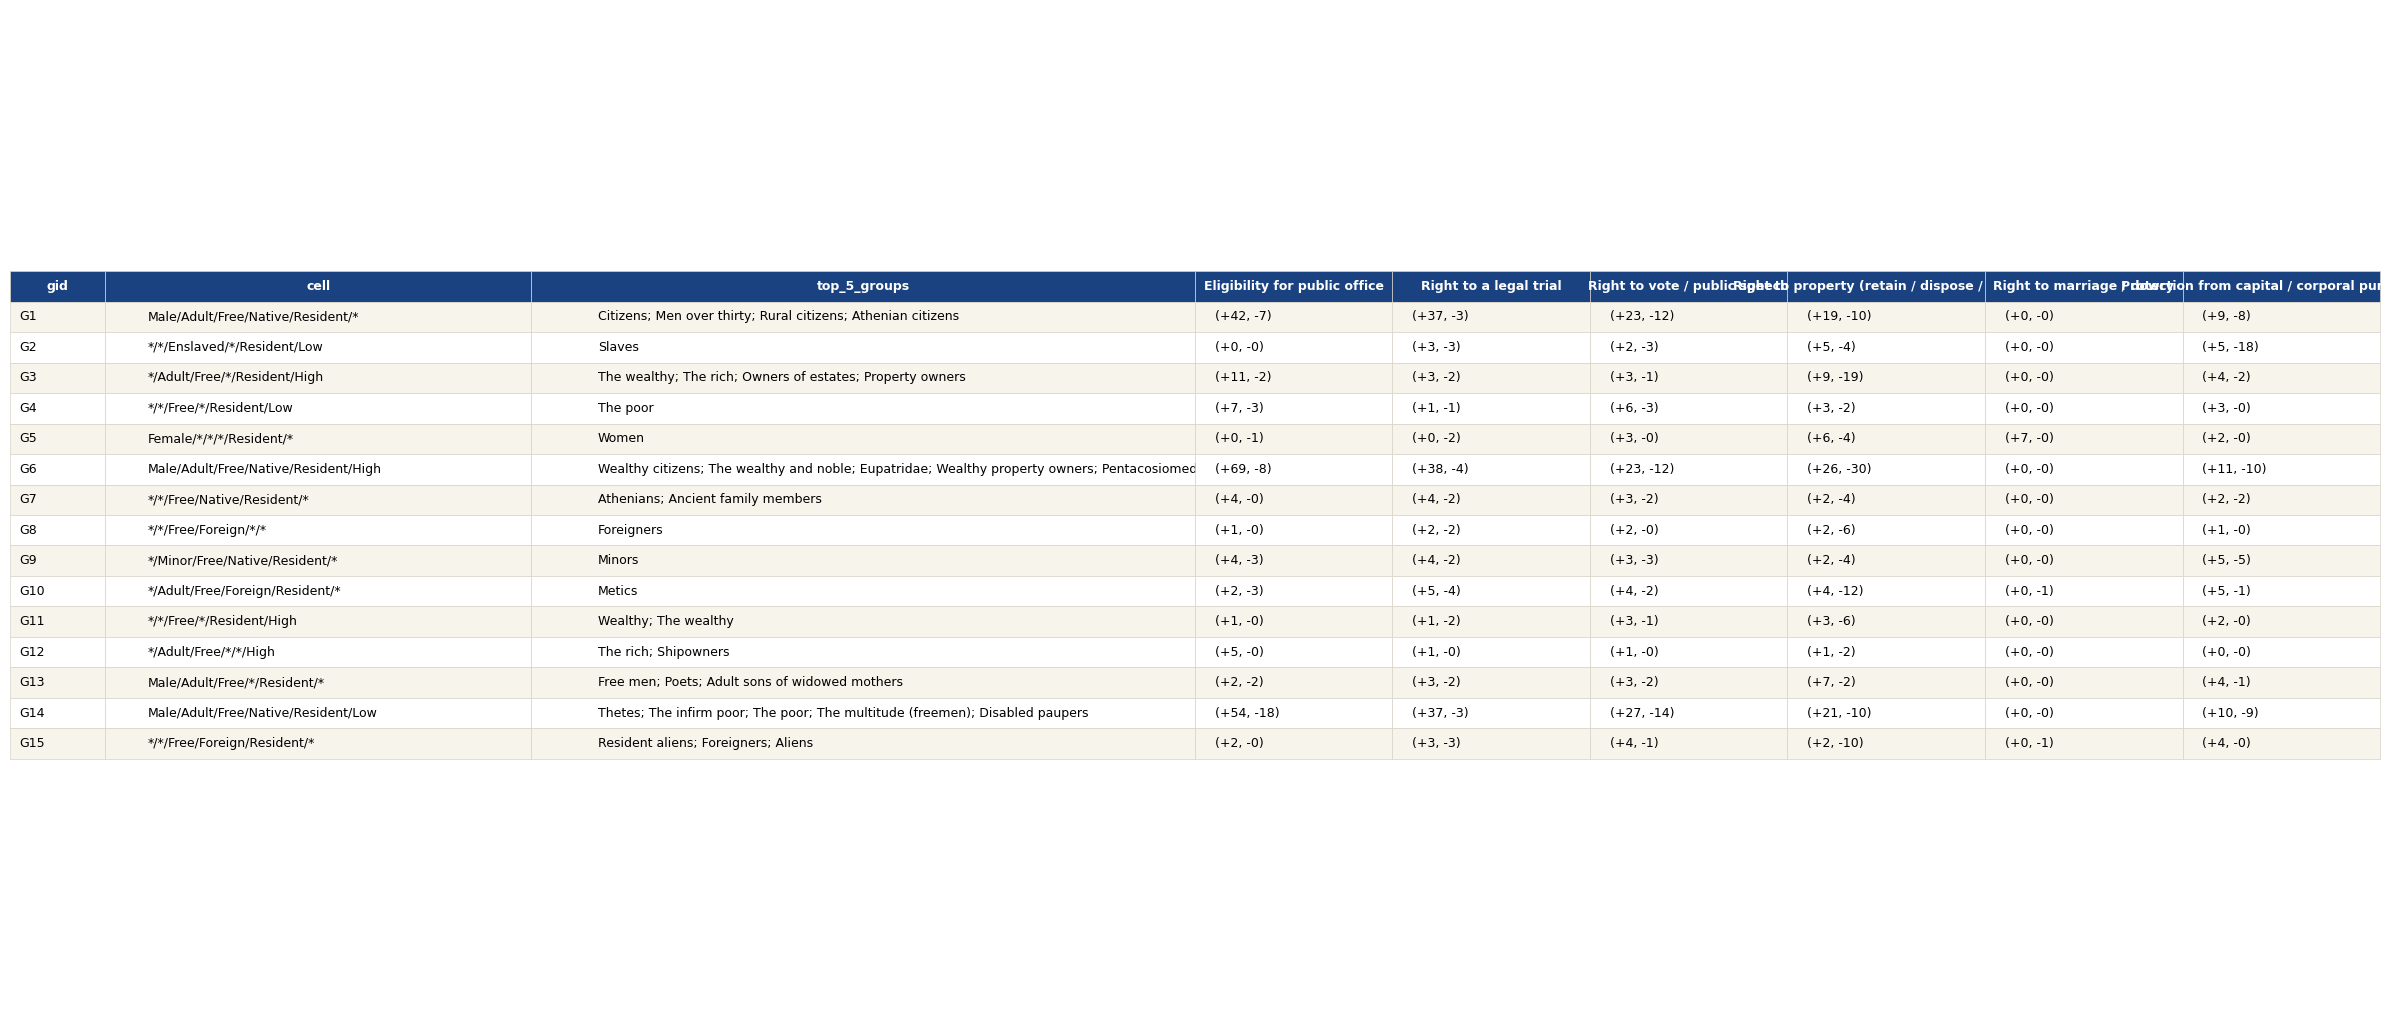

In [13]:
fig_width  = 24
fig_height = 0.65 * (len(display_table) + 1)

fig, ax = plt.subplots(figsize=(fig_width, fig_height))
ax.axis('off')

table = ax.table(
    cellText=display_table.values.astype(str),
    colLabels=display_table.columns,
    loc='center',
    cellLoc='left',
)
table.auto_set_font_size(False)
table.set_fontsize(9)
table.scale(1, 1.45)

header_face = '#1a4280'
header_text = '#ffffff'
zebra_a     = '#f7f4ec'
zebra_b     = '#ffffff'

for (row_idx, col_idx), cell in table.get_celld().items():
    cell.set_edgecolor('#d8d3c8')
    cell.set_linewidth(0.5)
    if row_idx == 0:
        cell.set_facecolor(header_face)
        cell.get_text().set_color(header_text)
        cell.get_text().set_weight('bold')
    else:
        cell.set_facecolor(zebra_a if row_idx % 2 else zebra_b)

column_widths = {
    'gid':           0.04,
    'cell':          0.18,
    'top_5_groups':  0.28,
}
remaining_cols = [c for c in display_table.columns if c not in column_widths]
even_width = (1 - sum(column_widths.values())) / max(len(remaining_cols), 1)
for col_idx, col_name in enumerate(display_table.columns):
    width = column_widths.get(col_name, even_width)
    for row_idx in range(len(display_table) + 1):
        table[(row_idx, col_idx)].set_width(width)

plt.tight_layout()
plt.show()

## Resource → criterion association

For each resource we count, across the in-scope rules, how often each criterion value appears in a `MORE` (access-granting) rule versus a `LESS` (access-denying) rule. The table below has one row per resource and lists the top three criterion values most positively associated with **gaining** the resource and the top three most associated with **losing** it.

Ranking uses the **net** count (a value like `ownership=Free` shows up in many MORE *and* LESS rules, so the raw count would list it on both sides). We rank the access side by `(MORE − LESS)` and the denial side by `(LESS − MORE)`, keeping only values with at least `MIN_SUPPORT` rules of evidence. Each entry shows `axis=value  (+more / -less)`.

*Unspecified* axis values are excluded — only rules that explicitly mention a criterion value count toward that value's tally.

In [14]:
TOP_K_PER_SIDE = 3
MIN_SUPPORT    = 2  # value must be mentioned in at least this many in-scope rules for the resource

axis_display = {
    'c_sex':              'sex',
    'c_age':              'age',
    'c_ownership_status': 'ownership',
    'c_ancestry':         'ancestry',
    'c_residence':        'residence',
    'c_wealth':           'wealth',
}

def is_specified(value):
    if pd.isna(value): return False
    text = str(value).strip().lower()
    return text not in ('', 'any', 'unspecified', 'middle')

criterion_long_rows = []
for _, rule in rules_in_scope.iterrows():
    for axis_name in AXES:
        raw_value = rule[axis_name]
        if not is_specified(raw_value):
            continue
        criterion_long_rows.append({
            'resource_bucket': rule['resource_bucket'],
            'axis':            axis_display[axis_name],
            'value':           str(raw_value).replace('_', ' ').capitalize(),
            'directionality':  rule['directionality'],
        })
criterion_long = pd.DataFrame(criterion_long_rows)

criterion_resource_counts = (
    criterion_long
        .groupby(['resource_bucket', 'axis', 'value', 'directionality'])
        .size()
        .unstack('directionality', fill_value=0)
        .reset_index()
)
for col in ('MORE', 'LESS'):
    if col not in criterion_resource_counts.columns:
        criterion_resource_counts[col] = 0
criterion_resource_counts['support']   = criterion_resource_counts['MORE'] + criterion_resource_counts['LESS']
criterion_resource_counts['net_more']  = criterion_resource_counts['MORE'] - criterion_resource_counts['LESS']
criterion_resource_counts['net_less']  = criterion_resource_counts['LESS'] - criterion_resource_counts['MORE']

def top_entries(df, net_column, k):
    ranked = (
        df[(df['support'] >= MIN_SUPPORT) & (df[net_column] > 0)]
          .sort_values(net_column, ascending=False)
          .head(k)
    )
    return '; '.join(
        f"{row['axis']}={row['value']}  (+{int(row['MORE'])} / -{int(row['LESS'])})"
        for _, row in ranked.iterrows()
    )

resource_criterion_table_rows = []
for resource_name in ORTHOGONAL_RESOURCES:
    sub = criterion_resource_counts[criterion_resource_counts['resource_bucket'] == resource_name]
    resource_criterion_table_rows.append({
        'resource':                       resource_name,
        'n_rules_more':                   int(sub['MORE'].sum()),
        'n_rules_less':                   int(sub['LESS'].sum()),
        'criteria_linked_to_access (+)':  top_entries(sub, 'net_more', TOP_K_PER_SIDE) or '—',
        'criteria_linked_to_denial (-)':  top_entries(sub, 'net_less', TOP_K_PER_SIDE) or '—',
    })

resource_criterion_table = pd.DataFrame(resource_criterion_table_rows)
print('resource_criterion_table.shape =', resource_criterion_table.shape)
resource_criterion_table

resource_criterion_table.shape = (6, 5)


,resource,n_rules_more,n_rules_less,criteria_linked_to_access (+),criteria_linked_to_denial (-)
0,Eligibility for public office,394,120,ownership=Free (+85 / -28); ancestry=Native (+63 / -11); residence=Resident (+80 / -29),age=Minor (+0 / -3); ancestry=Mixed (+0 / -2)
1,Right to a legal trial,208,25,ownership=Free (+43 / -4); residence=Resident (+45 / -7); age=Adult (+37 / -2),—
2,Right to vote / public speech,132,81,age=Adult (+23 / -11); sex=Male (+22 / -10); ancestry=Native (+22 / -11),ownership=Enslaved (+0 / -3); ancestry=Mixed (+0 / -2); wealth=Low (+4 / -5)
3,Right to property (retain / dispose / inherit),146,169,sex=Male (+17 / -10); ancestry=Native (+15 / -12); sex=Female (+8 / -5),wealth=High (+7 / -20); ancestry=Foreign (+1 / -10); ownership=Free (+32 / -41)
4,Right to marriage / dowry,37,3,sex=Female (+12 / -0); residence=Resident (+12 / -1); ancestry=Native (+4 / -0),—
5,Protection from capital / corporal punishment,78,114,ownership=Free (+16 / -11); ancestry=Foreign (+3 / -0); age=Adult (+10 / -9),ownership=Enslaved (+3 / -19); wealth=Low (+4 / -20); residence=Resident (+20 / -32)


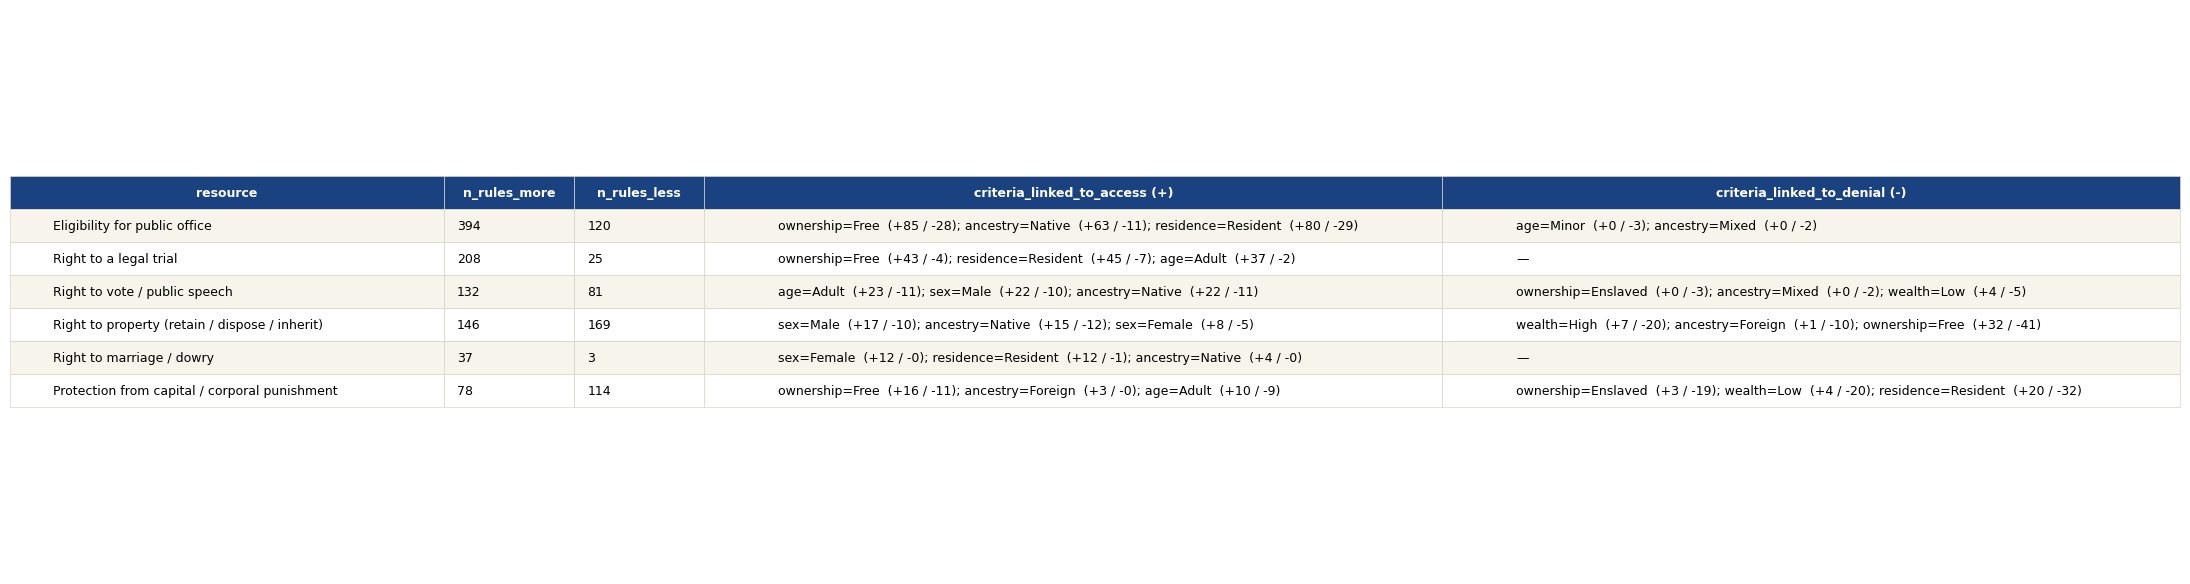

In [15]:
fig_width  = 22
fig_height = 0.85 * (len(resource_criterion_table) + 1)

fig, ax = plt.subplots(figsize=(fig_width, fig_height))
ax.axis('off')

table = ax.table(
    cellText=resource_criterion_table.values.astype(str),
    colLabels=resource_criterion_table.columns,
    loc='center',
    cellLoc='left',
)
table.auto_set_font_size(False)
table.set_fontsize(9)
table.scale(1, 1.6)

header_face = '#1a4280'
header_text = '#ffffff'
zebra_a     = '#f7f4ec'
zebra_b     = '#ffffff'

for (row_idx, col_idx), cell in table.get_celld().items():
    cell.set_edgecolor('#d8d3c8')
    cell.set_linewidth(0.5)
    if row_idx == 0:
        cell.set_facecolor(header_face)
        cell.get_text().set_color(header_text)
        cell.get_text().set_weight('bold')
    else:
        cell.set_facecolor(zebra_a if row_idx % 2 else zebra_b)

column_widths = {
    'resource':                       0.20,
    'n_rules_more':                   0.06,
    'n_rules_less':                   0.06,
    'criteria_linked_to_access (+)':  0.34,
    'criteria_linked_to_denial (-)':  0.34,
}
for col_idx, col_name in enumerate(resource_criterion_table.columns):
    width = column_widths.get(col_name, 0.15)
    for row_idx in range(len(resource_criterion_table) + 1):
        table[(row_idx, col_idx)].set_width(width)

plt.tight_layout()
plt.show()

## Threshold to a binary right vector — per-resource normalization

Resources are not equally attested in the corpus: *Eligibility for public office* has 117 rules but *Right to marriage / dowry* only 13. A flat threshold (e.g. count ≥ 2) under-rewards groups on common resources and over-rewards them on rare ones.

We normalize per resource. For each resource `R` we take the **maximum** integer count across all groups, then a group `G` *holds* `R` iff its share of that maximum is at or above a fixed cut-off:

$$
\text{bit}(G, R) \;=\; \begin{cases} 1 & \dfrac{\text{count}(G, R)}{\max_{G'} \text{count}(G', R)} \;\geq\; \tau \\ 0 & \text{otherwise.} \end{cases}
$$

`τ` is the same value for every resource (set below); this is a pure rescaling of evidence to the resource's own scale.

In [16]:
NORMALIZED_RIGHT_THRESHOLD = 0.30  # held iff count >= 30% of the resource's maximum

max_count_per_resource_corpus = integer_count.max(axis=0)
denom_corpus = np.where(max_count_per_resource_corpus > 0, max_count_per_resource_corpus, 1)
normalized_count = integer_count / denom_corpus
binary_right_matrix = (normalized_count >= NORMALIZED_RIGHT_THRESHOLD).astype(int)
n_rights_per_cell = binary_right_matrix.sum(axis=1)

print('max_count_per_resource_corpus:')
for r, m in zip(ORTHOGONAL_RESOURCES, max_count_per_resource_corpus):
    print(f'   {m:>4d}   {r}')
print()
print('binary_right_matrix.shape =', binary_right_matrix.shape)
print('rights count distribution:')
print(pd.Series(n_rights_per_cell).value_counts().sort_index().rename('n_cells').to_frame())

binary_right_table = pd.DataFrame({
    'gid':          corpus_cells['gid'].values,
    'cell':         corpus_cells['rule_criterion_signature'].values,
    'top_5_groups': corpus_cells['top_5_groups'].values,
    'rights':       [''.join(str(b) for b in binary_right_matrix[i]) for i in range(n_cells)],
    'n_rights':     n_rights_per_cell,
}).sort_values('n_rights', ascending=False).reset_index(drop=True)
binary_right_table.head(15)

max_count_per_resource_corpus:
     61   Eligibility for public office
     34   Right to a legal trial
     13   Right to vote / public speech
     11   Right to property (retain / dispose / inherit)
     11   Right to marriage / dowry
      6   Protection from capital / corporal punishment

binary_right_matrix.shape = (56, 6)
rights count distribution:
   n_cells
0       28
1       18
2        6
3        1
4        3


,gid,cell,top_5_groups,rights,n_rights
0,G1,Male/Adult/Free/Native/Resident/*,Citizens; Men over thirty; Rural citizens; Men who have prostituted themselves; Athenian citizens,111100,4
1,G14,Male/Adult/Free/Native/Resident/Low,Thetes; The infirm poor; The poor; The multitude (freemen); Disabled paupers,111100,4
2,G29,Male/Adult/Free/Native/Resident/Middle,Owners of military equipment; Zeugitae; The Zeugites,111100,4
3,G6,Male/Adult/Free/Native/Resident/High,Wealthy citizens; The wealthy and noble; Eupatridae; Wealthy property owners; Pentacosiomedimni,111000,3
4,G30,Male/Adult/Free/*/Resident/Middle,Sophists; Tax farmers and sureties,000101,2
5,G55,Female/*/Free/*/Resident/*,Women,000011,2
6,G41,Male/Adult/Free/Mixed/Resident/*,Citizens of non-citizen parentage,000101,2
7,G13,Male/Adult/Free/*/Resident/*,Free men; Poets; Adult sons of widowed mothers,000101,2
8,G31,Female/Adult/Free/*/Resident/*,Wives,000110,2
9,G5,Female/*/*/*/Resident/*,Women,000011,2


## Top-group right comparison — shared vs. distinguishing rights

To compare the best-attested corpus groups on a common footing, we line up the **top `N` groups** (ranked by rule attestation) as rows and the 6 rights as columns. Each cell is the binary `bit(G, R)` from the per-resource threshold above: a group either **holds** the right (`✓`) or it does **not** (`·`).

From this matrix we read off three sets:

- **shared** — rights every top group holds,
- **absent** — rights no top group holds,
- **distinguishing** — rights that separate the top groups (the axes of comparison).


In [17]:
N_TOP_GROUPS_COMPARE = 12

RIGHT_SHORT = {
    'Eligibility for public office':                  'Office',
    'Right to a legal trial':                         'Trial',
    'Right to vote / public speech':                  'Vote/Speech',
    'Right to property (retain / dispose / inherit)': 'Property',
    'Right to marriage / dowry':                      'Marriage',
    'Protection from capital / corporal punishment':  'Protect-Punish',
}
short_cols = [RIGHT_SHORT[r] for r in ORTHOGONAL_RESOURCES]

top_compare = pd.DataFrame(binary_right_matrix[:N_TOP_GROUPS_COMPARE], columns=short_cols)
top_compare.insert(0, 'gid',            corpus_cells['gid'].head(N_TOP_GROUPS_COMPARE).values)
top_compare.insert(1, 'cell',           corpus_cells['rule_criterion_signature'].head(N_TOP_GROUPS_COMPARE).values)
top_compare.insert(2, 'example_groups', corpus_cells['top_5_groups'].head(N_TOP_GROUPS_COMPARE).map(clean_top_groups).values)
top_compare.insert(3, 'n_rules',        corpus_cells['n_rules'].head(N_TOP_GROUPS_COMPARE).values)

shared_rights  = [c for c in short_cols if top_compare[c].all()]
absent_rights  = [c for c in short_cols if not top_compare[c].any()]
distinguishing = [c for c in short_cols if c not in shared_rights + absent_rights]

print(f'Top {N_TOP_GROUPS_COMPARE} corpus groups by rule attestation')
print('  shared by all      :', shared_rights  or '(none)')
print('  absent in all      :', absent_rights  or '(none)')
print('  distinguishing set :', distinguishing or '(none)')

display_compare = top_compare.drop(columns='example_groups').copy()
for c in short_cols:
    display_compare[c] = display_compare[c].map({1: '✓', 0: '·'})
display_compare

Top 12 corpus groups by rule attestation
  shared by all      : (none)
  absent in all      : (none)
  distinguishing set : ['Office', 'Trial', 'Vote/Speech', 'Property', 'Marriage', 'Protect-Punish']


,gid,cell,n_rules,Office,Trial,Vote/Speech,Property,Marriage,Protect-Punish
0,G1,Male/Adult/Free/Native/Resident/*,122,✓,✓,✓,✓,·,·
1,G2,*/*/Enslaved/*/Resident/Low,36,·,·,·,·,·,·
2,G3,*/Adult/Free/*/Resident/High,25,·,·,·,·,·,✓
3,G4,*/*/Free/*/Resident/Low,18,·,·,·,·,·,✓
4,G5,Female/*/*/*/Resident/*,18,·,·,·,·,✓,✓
5,G6,Male/Adult/Free/Native/Resident/High,15,✓,✓,✓,·,·,·
6,G7,*/*/Free/Native/Resident/*,11,·,·,·,·,·,·
7,G8,*/*/Free/Foreign/*/*,9,·,·,·,·,·,·
8,G9,*/Minor/Free/Native/Resident/*,8,·,·,·,·,·,·
9,G10,*/Adult/Free/Foreign/Resident/*,8,·,·,·,·,·,✓


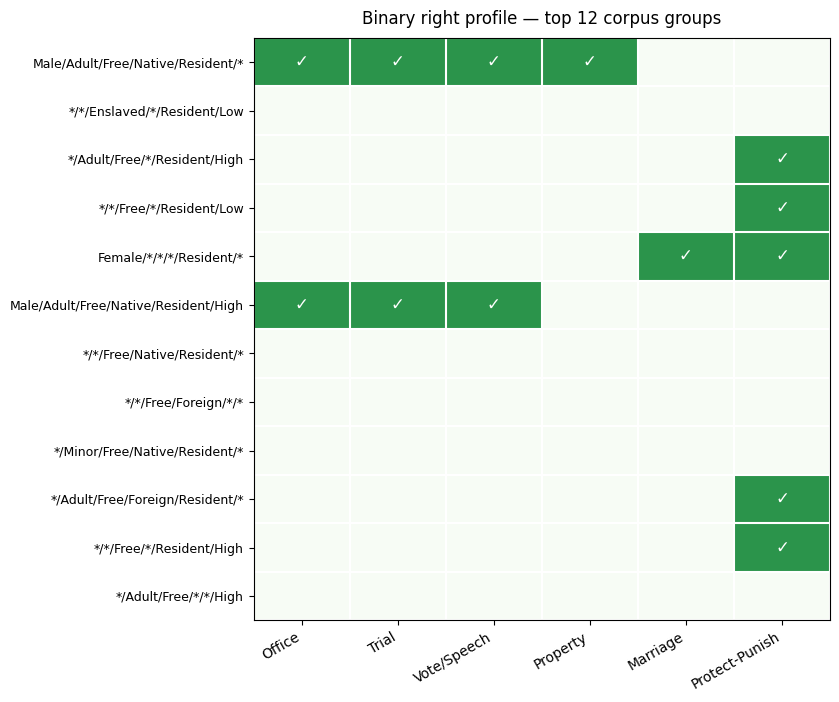

In [18]:
import matplotlib.pyplot as plt

M = binary_right_matrix[:N_TOP_GROUPS_COMPARE]
fig, ax = plt.subplots(figsize=(8.5, 0.46 * N_TOP_GROUPS_COMPARE + 1.6))
ax.imshow(M, cmap='Greens', vmin=0, vmax=1.4, aspect='auto')

ax.set_xticks(range(len(short_cols)))
ax.set_xticklabels(short_cols, rotation=30, ha='right', fontsize=10)
ax.set_yticks(range(N_TOP_GROUPS_COMPARE))
ax.set_yticklabels(corpus_cells['rule_criterion_signature'].head(N_TOP_GROUPS_COMPARE), fontsize=9)

for i in range(M.shape[0]):
    for j in range(M.shape[1]):
        if M[i, j]:
            ax.text(j, i, '✓', ha='center', va='center', color='white', fontsize=12)

ax.set_xticks(np.arange(-.5, len(short_cols), 1), minor=True)
ax.set_yticks(np.arange(-.5, N_TOP_GROUPS_COMPARE, 1), minor=True)
ax.grid(which='minor', color='white', linewidth=1.5)
ax.tick_params(which='minor', length=0)
ax.set_title(f'Binary right profile — top {N_TOP_GROUPS_COMPARE} corpus groups', fontsize=12, pad=10)
plt.tight_layout()
plt.show()

## Imputation — step by step

### Step 1. Each criterion-value has an empirical ability to grant each right

For every axis-value pair (e.g. `c_sex = Male`, `c_sex = Female`, `c_age = Adult`, …) we look at the corpus cells that carry that value on that axis and ask: *what fraction of them hold each of the 6 rights?*

$$ P(\text{right } r \mid \text{axis } A = v) \;=\; \dfrac{\#\{\text{corpus cells with } A = v \text{ AND } \text{bit}_r = 1\}}{\#\{\text{corpus cells with } A = v\}} $$

The table below has one row per `(axis, value)` and one column per resource. The value in each cell is the conditional probability, in `[0, 1]`. It is `0` when no observed cell with that value holds the right, and `1` when every observed cell does.

In [19]:
axis_value_pairs = []
for axis_idx, axis_name in enumerate(AXES):
    binary_values = list(AXIS_BINARY_PAIR[axis_name]) if axis_name in AXIS_BINARY_PAIR else ['High', 'Low']
    for value in binary_values:
        axis_value_pairs.append((axis_idx, axis_name, value))

axis_value_probability = {}
axis_value_support     = {}
for axis_idx, axis_name, value in axis_value_pairs:
    mask = np.array([sig.split('/')[axis_idx] == value for sig in cell_signatures])
    n_support = int(mask.sum())
    axis_value_support[(axis_name, value)] = n_support
    if n_support == 0:
        axis_value_probability[(axis_name, value)] = np.zeros(n_resources)
    else:
        axis_value_probability[(axis_name, value)] = binary_right_matrix[mask].mean(axis=0)

axis_value_probability_table = pd.DataFrame([
    {
        'axis':                       axis_name,
        'value':                      value,
        'n_corpus_cells_with_value':  axis_value_support[(axis_name, value)],
        **{ORTHOGONAL_RESOURCES[r]: round(axis_value_probability[(axis_name, value)][r], 2)
           for r in range(n_resources)},
    }
    for axis_idx, axis_name, value in axis_value_pairs
])
print('axis_value_probability_table.shape =', axis_value_probability_table.shape)
axis_value_probability_table

axis_value_probability_table.shape = (12, 9)


,axis,value,n_corpus_cells_with_value,Eligibility for public office,Right to a legal trial,Right to vote / public speech,Right to property (retain / dispose / inherit),Right to marriage / dowry,Protection from capital / corporal punishment
0,c_sex,Male,15,0.27,0.27,0.27,0.53,0.00,0.33
1,c_sex,Female,8,0.00,0.00,0.00,0.12,0.88,0.25
2,c_age,Adult,22,0.18,0.18,0.18,0.32,0.09,0.32
3,c_age,Minor,4,0.00,0.00,0.00,0.00,0.25,0.00
4,c_ownership_status,Free,40,0.10,0.10,0.10,0.22,0.15,0.35
5,c_ownership_status,Enslaved,3,0.00,0.00,0.00,0.00,0.00,0.00
6,c_ancestry,Native,22,0.18,0.18,0.18,0.23,0.18,0.00
7,c_ancestry,Foreign,7,0.00,0.00,0.00,0.00,0.00,0.57
8,c_residence,Resident,43,0.09,0.09,0.09,0.21,0.16,0.40
9,c_residence,Non resident,2,0.00,0.00,0.00,0.00,0.00,0.00


### Step 2. Reconstruct each atomic cell by the *geometric mean* of its six axis-value probabilities

We combine the six axis-value probabilities into a single number per resource per atomic cell. We use the **geometric mean** rather than the arithmetic mean: it is far more *aggressive* — if **any** axis-value has probability 0 for a right (no observed cell with that axis-value holds that right), the geometric mean is 0. So a single "this axis-value never carries this right" suppresses the cell entirely:

$$ P\bigl(r \mid (v_1, \dots, v_6)\bigr) \;=\; \left( \prod_{i=1}^{6} P(r \mid A_i = v_i) \right)^{1/6} $$

This is the difference that makes `Female/Adult/Enslaved/...` lose office, even if its other axes (Adult, Free → wait, here it's Enslaved) carry some support: as soon as `c_ownership=Enslaved` has 0 probability for office, the whole product is 0. The arithmetic mean we used before diluted this; the geometric mean does not.

In [20]:
def all_atomic_combinations():
    options = [list(AXIS_BINARY_PAIR[axis]) for axis in AXES if axis != 'c_wealth']
    options.append(['High', 'Low'])
    for combo in product(*options):
        yield '/'.join(combo)

imputed_signatures = list(all_atomic_combinations())
assert len(imputed_signatures) == 64

imputed_probability_matrix = np.zeros((len(imputed_signatures), n_resources))
for i, signature in enumerate(imputed_signatures):
    per_axis_rows = np.stack([
        axis_value_probability[(AXES[axis_idx], value)]
        for axis_idx, value in enumerate(signature.split('/'))
    ])
    with np.errstate(divide='ignore', invalid='ignore'):
        log_probs = np.log(per_axis_rows)
        log_mean  = log_probs.mean(axis=0)
        geometric_mean = np.exp(log_mean)
    imputed_probability_matrix[i] = np.where(np.isfinite(geometric_mean), geometric_mean, 0.0)

imputed_probability_table = pd.DataFrame(
    imputed_probability_matrix.round(3),
    columns=ORTHOGONAL_RESOURCES,
)
imputed_probability_table.insert(0, 'atomic_cell', imputed_signatures)
print('imputed_probability_matrix.shape =', imputed_probability_matrix.shape)
imputed_probability_table.head(15)

imputed_probability_matrix.shape = (64, 6)


,atomic_cell,Eligibility for public office,Right to a legal trial,Right to vote / public speech,Right to property (retain / dispose / inherit),Right to marriage / dowry,Protection from capital / corporal punishment
0,Male/Adult/Free/Native/Resident/High,0.145,0.145,0.145,0.000,0.0,0.000
1,Male/Adult/Free/Native/Resident/Low,0.145,0.145,0.145,0.242,0.0,0.000
2,Male/Adult/Free/Native/Non resident/High,0.000,0.000,0.000,0.000,0.0,0.000
3,Male/Adult/Free/Native/Non resident/Low,0.000,0.000,0.000,0.000,0.0,0.000
4,Male/Adult/Free/Foreign/Resident/High,0.000,0.000,0.000,0.000,0.0,0.351
5,Male/Adult/Free/Foreign/Resident/Low,0.000,0.000,0.000,0.000,0.0,0.351
6,Male/Adult/Free/Foreign/Non resident/High,0.000,0.000,0.000,0.000,0.0,0.000
7,Male/Adult/Free/Foreign/Non resident/Low,0.000,0.000,0.000,0.000,0.0,0.000
8,Male/Adult/Enslaved/Native/Resident/High,0.000,0.000,0.000,0.000,0.0,0.000
9,Male/Adult/Enslaved/Native/Resident/Low,0.000,0.000,0.000,0.000,0.0,0.000


### Step 3. Per-resource normalization and threshold → binary right vector

The averaged probabilities live on different scales for different resources (because some rights are widely attested, others rarely). We normalize each resource column by its maximum across the 64 atomic cells, then a cell *holds* the right iff its normalized score is at or above `IMPUTATION_THRESHOLD`. This is the same rule used at the corpus-cell level.

In [21]:
IMPUTATION_THRESHOLD = 0.30  # held iff normalised probability >= 30% of the resource's maximum across atomic cells

max_probability_per_resource = imputed_probability_matrix.max(axis=0)
denom_imputed = np.where(max_probability_per_resource > 0, max_probability_per_resource, 1)
imputed_normalized = imputed_probability_matrix / denom_imputed
imputed_binary_matrix = (imputed_normalized >= IMPUTATION_THRESHOLD).astype(int)

print('max_probability_per_resource:')
for r, m in zip(ORTHOGONAL_RESOURCES, max_probability_per_resource):
    print(f'   {m:.3f}   {r}')

observed_atomic_set = set(rules_in_scope['rule_criterion_signature'])
imputed_summary = pd.DataFrame({
    'criterion':            imputed_signatures,
    'observed_in_corpus':   [sig in observed_atomic_set for sig in imputed_signatures],
    'mean_probability':     [round(imputed_probability_matrix[i].mean(), 3)
                             for i in range(len(imputed_signatures))],
    'rights':               [''.join(str(b) for b in imputed_binary_matrix[i])
                             for i in range(len(imputed_signatures))],
    'n_rights':             imputed_binary_matrix.sum(axis=1),
}).sort_values('n_rights', ascending=False).reset_index(drop=True)

print()
print('imputed_summary.shape =', imputed_summary.shape)
print('rights count distribution:')
print(imputed_summary['n_rights'].value_counts().sort_index().rename('n_cells').to_frame())
imputed_summary.head(15)

max_probability_per_resource:
   0.145   Eligibility for public office
   0.145   Right to a legal trial
   0.145   Right to vote / public speech
   0.242   Right to property (retain / dispose / inherit)
   0.245   Right to marriage / dowry
   0.351   Protection from capital / corporal punishment

imputed_summary.shape = (64, 5)
rights count distribution:
          n_cells
n_rights         
0              55
1               7
3               1
4               1


,criterion,observed_in_corpus,mean_probability,rights,n_rights
0,Male/Adult/Free/Native/Resident/Low,True,0.113,111100,4
1,Male/Adult/Free/Native/Resident/High,True,0.072,111000,3
2,Female/Minor/Free/Native/Resident/High,False,0.041,000010,1
3,Female/Adult/Free/Foreign/Resident/Low,False,0.056,000001,1
4,Female/Adult/Free/Foreign/Resident/High,False,0.056,000001,1
5,Female/Adult/Free/Native/Resident/Low,False,0.032,000100,1
6,Female/Adult/Free/Native/Resident/High,True,0.034,000010,1
7,Male/Adult/Free/Foreign/Resident/Low,False,0.058,000001,1
8,Male/Adult/Free/Foreign/Resident/High,False,0.058,000001,1
9,Male/Adult/Free/Foreign/Non resident/Low,False,0.000,000000,0


### Worked example — `Female/Adult/Free/Native/Resident/Low`

Below we trace one atomic cell end-to-end:

1. Pull the six rows of `axis_value_probability_table` for its six axis-values.
2. Average those six rows column-by-column.
3. Apply the 0.50 threshold.

The result is the imputed binary right vector for *poor adult Native free women*.

In [22]:
example_signature = 'Female/Adult/Free/Native/Resident/Low'
example_axis_values = list(zip(AXES, example_signature.split('/')))

example_rows = pd.DataFrame([
    {
        'axis':  axis_name,
        'value': value,
        **{ORTHOGONAL_RESOURCES[r]: round(axis_value_probability[(axis_name, value)][r], 3)
           for r in range(n_resources)},
    }
    for axis_name, value in example_axis_values
])

per_axis_values = example_rows.iloc[:, 2:].values
with np.errstate(divide='ignore', invalid='ignore'):
    example_geo_mean = np.exp(np.log(per_axis_values).mean(axis=0))
example_geo_mean = np.where(np.isfinite(example_geo_mean), example_geo_mean, 0.0).round(3)
example_normalized = (example_geo_mean / denom_imputed).round(3)
example_binary = (example_normalized >= IMPUTATION_THRESHOLD).astype(int)

example_view = pd.concat([
    example_rows,
    pd.DataFrame([{'axis': '-- geometric mean --', 'value': '',
                   **{ORTHOGONAL_RESOURCES[r]: example_geo_mean[r] for r in range(n_resources)}}]),
    pd.DataFrame([{'axis': '-- normalised --', 'value': '',
                   **{ORTHOGONAL_RESOURCES[r]: example_normalized[r] for r in range(n_resources)}}]),
    pd.DataFrame([{'axis': '-- binary --', 'value': '',
                   **{ORTHOGONAL_RESOURCES[r]: int(example_binary[r]) for r in range(n_resources)}}]),
], ignore_index=True)
print(f'Worked example: {example_signature}')
example_view

Worked example: Female/Adult/Free/Native/Resident/Low


,axis,value,Eligibility for public office,Right to a legal trial,Right to vote / public speech,Right to property (retain / dispose / inherit),Right to marriage / dowry,Protection from capital / corporal punishment
0,c_sex,Female,0.000,0.000,0.000,0.125,0.875,0.250
1,c_age,Adult,0.182,0.182,0.182,0.318,0.091,0.318
2,c_ownership_status,Free,0.100,0.100,0.100,0.225,0.150,0.350
3,c_ancestry,Native,0.182,0.182,0.182,0.227,0.182,0.000
4,c_residence,Resident,0.093,0.093,0.093,0.209,0.163,0.395
5,c_wealth,Low,0.111,0.111,0.111,0.111,0.000,0.222
6,-- geometric mean --,,0.000,0.000,0.000,0.190,0.000,0.000
7,-- normalised --,,0.000,0.000,0.000,0.785,0.000,0.000
8,-- binary --,,0.000,0.000,0.000,1.000,0.000,0.000


## Hasse diagram — atomic-group rights inclusion

For each atomic combination, two groups `A` and `B` sit in the order `A ⪰ B` iff `rights(A) ⊇ rights(B)` (every right of `B` is also held by `A`). Edges drawn are covering relations only — direct dominance steps.

In [23]:
import networkx as nx

def specific_emic_name(criterion_signature):
    sex, age, ownership, ancestry, residence, wealth = criterion_signature.split('/')
    if ownership == 'Enslaved':
        if age == 'Minor':
            core = 'slave girls' if sex == 'Female' else 'slave boys'
        else:
            core = 'slave women' if sex == 'Female' else 'slave men'
    elif age == 'Minor':
        if sex == 'Female':
            core = 'girls' if ancestry == 'Native' else 'foreign girls'
        else:
            core = 'boys'  if ancestry == 'Native' else 'foreign boys'
    elif sex == 'Female':
        core = 'wives' if ancestry == 'Native' else 'foreign women'
    else:
        core = 'citizens' if ancestry == 'Native' else 'foreign men'
    modifiers = ['Wealthy' if wealth == 'High' else 'Poor']
    if ancestry == 'Foreign' and ownership == 'Enslaved':
        modifiers.append('foreign')
    if residence == 'Non resident':
        modifiers.append('non-resident')
    return ' '.join(modifiers + [core])

imputed_idx = {sig: i for i, sig in enumerate(imputed_signatures)}
rights_set_per_atomic = {
    sig: frozenset(np.where(imputed_binary_matrix[imputed_idx[sig]] == 1)[0])
    for sig in imputed_signatures
}

N_TOP_BY_RIGHTS    = 8
N_BOTTOM_BY_RIGHTS = 6

atomic_by_rights = sorted(imputed_signatures,
                          key=lambda s: -int(imputed_binary_matrix[imputed_idx[s]].sum()))
observed_atomic  = set(rules_in_scope['rule_criterion_signature']) & set(imputed_signatures)

shown_atomic = sorted(
    set(atomic_by_rights[:N_TOP_BY_RIGHTS])
    | set(atomic_by_rights[-N_BOTTOM_BY_RIGHTS:])
    | observed_atomic,
    key=lambda s: -int(imputed_binary_matrix[imputed_idx[s]].sum()),
)

hasse_full = nx.DiGraph()
for sig in shown_atomic:
    hasse_full.add_node(
        sig,
        n_rights=int(imputed_binary_matrix[imputed_idx[sig]].sum()),
        emic=specific_emic_name(sig),
        observed=(sig in observed_atomic),
    )
for a in shown_atomic:
    for b in shown_atomic:
        if a == b: continue
        if rights_set_per_atomic[b] < rights_set_per_atomic[a]:
            hasse_full.add_edge(a, b)
hasse_covering = nx.transitive_reduction(hasse_full)
for node, data in hasse_full.nodes(data=True):
    if node in hasse_covering.nodes:
        hasse_covering.nodes[node].update(data)

print('shown atomic combinations =', len(shown_atomic))
print('observed (subset)         =', sum(1 for s in shown_atomic if s in observed_atomic))
print('covering edges            =', hasse_covering.number_of_edges())
pd.DataFrame([
    {'criterion': sig,
     'emic':      specific_emic_name(sig),
     'n_rights':  int(imputed_binary_matrix[imputed_idx[sig]].sum()),
     'observed':  sig in observed_atomic}
    for sig in shown_atomic
])

shown atomic combinations = 14
observed (subset)         = 3
covering edges            = 44


,criterion,emic,n_rights,observed
0,Male/Adult/Free/Native/Resident/Low,Poor citizens,4,True
1,Male/Adult/Free/Native/Resident/High,Wealthy citizens,3,True
2,Female/Adult/Free/Native/Resident/High,Wealthy wives,1,True
3,Male/Adult/Free/Foreign/Resident/Low,Poor foreign men,1,False
4,Female/Adult/Free/Foreign/Resident/Low,Poor foreign women,1,False
5,Female/Adult/Free/Native/Resident/Low,Poor wives,1,False
6,Female/Adult/Free/Foreign/Resident/High,Wealthy foreign women,1,False
7,Male/Adult/Free/Foreign/Resident/High,Wealthy foreign men,1,False
8,Female/Minor/Enslaved/Foreign/Resident/Low,Poor foreign slave girls,0,False
9,Female/Minor/Enslaved/Foreign/Non resident/High,Wealthy foreign non-resident slave girls,0,False


In [24]:
Y_BAND_SPACING = 3.4
X_BAND_PADDING = 3.6

nodes_by_n_rights = {}
for atomic in hasse_covering.nodes:
    nodes_by_n_rights.setdefault(hasse_covering.nodes[atomic]['n_rights'], []).append(atomic)

rights_level_to_y_rank = {n: i for i, n in enumerate(sorted(nodes_by_n_rights.keys()))}
max_nodes_per_band = max(len(v) for v in nodes_by_n_rights.values())

node_positions = {}
for n_rights, atomic_in_band in nodes_by_n_rights.items():
    atomic_in_band.sort()
    n = len(atomic_in_band)
    for i, atomic in enumerate(atomic_in_band):
        node_positions[atomic] = (
            (i - (n - 1) / 2) * X_BAND_PADDING * (max_nodes_per_band / max(n, 1)),
            rights_level_to_y_rank[n_rights] * Y_BAND_SPACING,
        )

pd.DataFrame([
    {'criterion': sig,
     'emic':      hasse_covering.nodes[sig]['emic'],
     'n_rights':  hasse_covering.nodes[sig]['n_rights'],
     'x':         round(node_positions[sig][0], 2),
     'y':         round(node_positions[sig][1], 2)}
    for sig in hasse_covering.nodes
])

,criterion,emic,n_rights,x,y
0,Male/Adult/Free/Native/Resident/Low,Poor citizens,4,0.0,10.2
1,Male/Adult/Free/Native/Resident/High,Wealthy citizens,3,0.0,6.8
2,Female/Adult/Free/Native/Resident/High,Wealthy wives,1,-1.8,3.4
3,Male/Adult/Free/Foreign/Resident/Low,Poor foreign men,1,9.0,3.4
4,Female/Adult/Free/Foreign/Resident/Low,Poor foreign women,1,-5.4,3.4
5,Female/Adult/Free/Native/Resident/Low,Poor wives,1,1.8,3.4
6,Female/Adult/Free/Foreign/Resident/High,Wealthy foreign women,1,-9.0,3.4
7,Male/Adult/Free/Foreign/Resident/High,Wealthy foreign men,1,5.4,3.4
8,Female/Minor/Enslaved/Foreign/Resident/Low,Poor foreign slave girls,0,1.8,0.0
9,Female/Minor/Enslaved/Foreign/Non resident/High,Wealthy foreign non-resident slave girls,0,-9.0,0.0


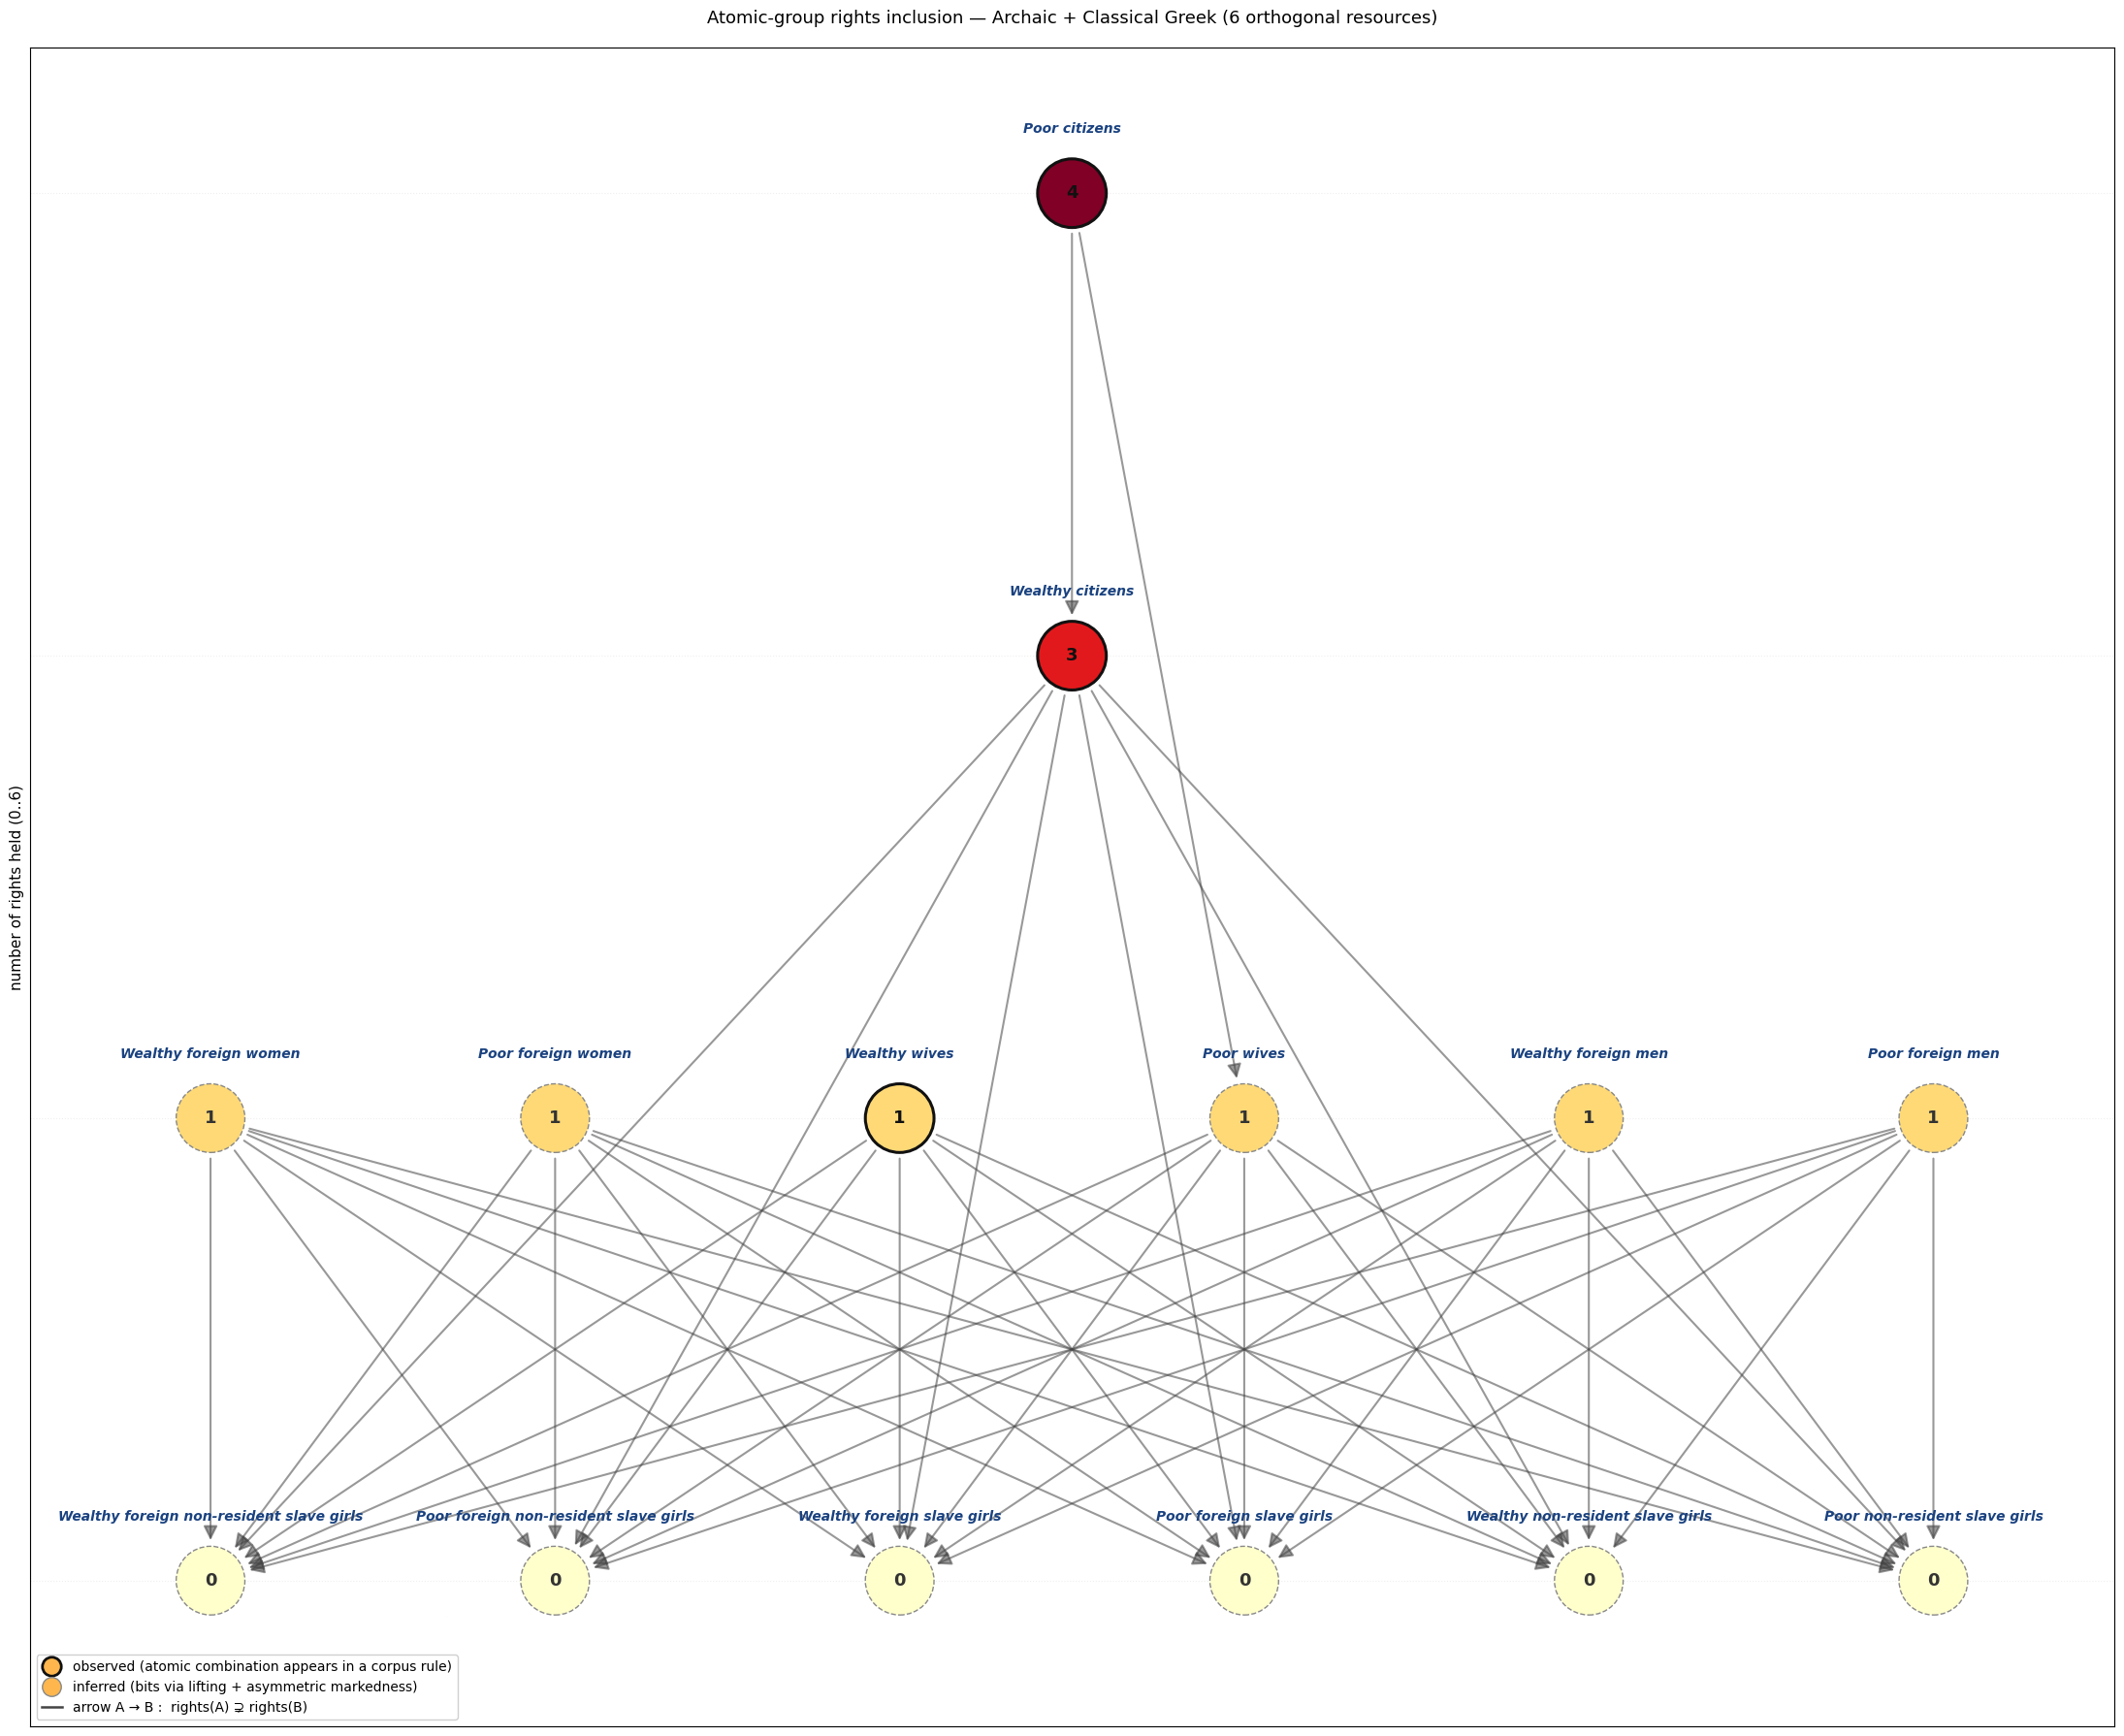

In [25]:
from matplotlib.lines import Line2D

fig, ax = plt.subplots(figsize=(22, 18))

nx.draw_networkx_edges(
    hasse_covering, node_positions, ax=ax,
    arrows=True, arrowstyle='-|>', arrowsize=22,
    width=1.5, alpha=0.55, edge_color='#444',
    connectionstyle='arc3,rad=0.0',
    min_target_margin=30, min_source_margin=30,
    node_size=2600,
)

observed_atomic_nodes = [s for s in hasse_covering.nodes if hasse_covering.nodes[s]['observed']]
inferred_atomic_nodes = [s for s in hasse_covering.nodes if not hasse_covering.nodes[s]['observed']]

n_rights_max = max(hasse_covering.nodes[s]['n_rights'] for s in hasse_covering.nodes)

if observed_atomic_nodes:
    nx.draw_networkx_nodes(
        hasse_covering, node_positions, ax=ax, nodelist=observed_atomic_nodes,
        node_size=2600,
        node_color=[hasse_covering.nodes[s]['n_rights'] for s in observed_atomic_nodes],
        cmap='YlOrRd', vmin=0, vmax=n_rights_max,
        edgecolors='#111', linewidths=2.2,
    )
if inferred_atomic_nodes:
    inferred_artist = nx.draw_networkx_nodes(
        hasse_covering, node_positions, ax=ax, nodelist=inferred_atomic_nodes,
        node_size=2600,
        node_color=[hasse_covering.nodes[s]['n_rights'] for s in inferred_atomic_nodes],
        cmap='YlOrRd', vmin=0, vmax=n_rights_max,
        edgecolors='#888', linewidths=1.0,
    )
    inferred_artist.set_linestyle('--')

for sig in hasse_covering.nodes:
    x, y = node_positions[sig]
    ax.text(x, y + 0.42, hasse_covering.nodes[sig]['emic'],
            ha='center', va='bottom', fontsize=10, fontweight='bold',
            style='italic', color='#1a4280')
    ax.text(x, y, str(hasse_covering.nodes[sig]['n_rights']),
            ha='center', va='center', fontsize=13, fontweight='bold',
            color='#111' if hasse_covering.nodes[sig]['observed'] else '#333')

ax.set_title('Atomic-group rights inclusion — Archaic + Classical Greek (6 orthogonal resources)',
             fontsize=13, pad=18)
ax.set_ylabel('number of rights held (0..6)', fontsize=11)
sorted_levels = sorted(rights_level_to_y_rank.keys())
ax.set_yticks([rights_level_to_y_rank[n] * Y_BAND_SPACING for n in sorted_levels])
ax.set_yticklabels([str(n) for n in sorted_levels])
ax.set_xticks([])
ax.legend(handles=[
    Line2D([0], [0], marker='o', color='w', markerfacecolor='#ffb74d',
           markeredgecolor='#111', markeredgewidth=2.0, markersize=14,
           label='observed (atomic combination appears in a corpus rule)'),
    Line2D([0], [0], marker='o', color='w', markerfacecolor='#ffb74d',
           markeredgecolor='#888', markeredgewidth=1.0, markersize=14,
           label='inferred (bits via lifting + asymmetric markedness)'),
    Line2D([0], [0], color='#444', lw=1.8,
           label='arrow A → B :  rights(A) ⊋ rights(B)'),
], loc='lower left', fontsize=10, framealpha=0.92, handlelength=1.5)
ax.grid(axis='y', alpha=0.20, linestyle=':')
ax.set_facecolor('white')
plt.tight_layout()
plt.show()